In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

In [2]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

In [3]:
spotify = pd.read_csv("spotify_merged_clean.csv")

In [4]:
continuous_features = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo'
]

spotify[continuous_features] = StandardScaler().fit_transform(spotify[continuous_features])

spotify.drop(columns=['key', 'mode'], inplace=True)

# If you want a clustering input table, it can now be taken directly from spotify.
X_for_clustering = spotify[continuous_features].copy()

spotify[continuous_features]

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,1.868896,-1.123959,-0.335257,0.919773,-0.678968,-0.512296,-0.311653,-0.160929,-0.605689
1,0.592912,-0.364169,-1.029071,-0.417897,-0.909587,0.052991,-0.538150,-1.418237,-0.063065
2,0.553037,0.493659,0.944242,0.840984,-0.732788,-0.521856,-0.688270,1.418466,1.355952
3,-0.358380,-0.891120,-1.098452,-0.567597,-0.910132,1.764826,-0.640337,-0.929284,0.276147
4,0.570126,-1.013667,-0.380699,-0.615746,-0.050149,-0.484697,-0.655612,0.359068,-0.842090
...,...,...,...,...,...,...,...,...,...
106003,0.382146,0.755092,-0.657008,-0.474801,-0.084172,2.438127,-0.609786,-1.255252,0.107221
106004,2.170802,-0.188518,0.399132,0.753440,-0.704950,-0.521837,0.004389,0.673395,0.276793
106005,-0.705858,-0.445867,0.351863,-0.585981,1.298427,-0.520496,-0.517080,0.712201,0.692663
106006,-1.816647,1.257534,0.264629,-0.037081,-0.913043,-0.501847,0.868237,-1.045701,1.737234


In [5]:
GENRE_MAPPING = {
    # Rock
    "rock": "Rock",
    "alt-rock": "Rock",
    "album rock": "Rock",
    "classic rock": "Rock",
    "hard-rock": "Rock",
    "hard rock": "Rock",
    "psych-rock": "Rock",
    "rock-n-roll": "Rock",
    "rockabilly": "Rock",
    "grunge": "Rock",
    "j-rock": "Rock",
    "permanent wave": "Rock",

    # Punk / Alternative
    "alternative": "Alternative",
    "indie": "Alternative",
    "indie-pop": "Alternative",
    "indie poptimism": "Alternative",
    "emo": "Alternative",
    "goth": "Alternative",
    "punk": "Alternative",
    "punk-rock": "Alternative",

    # Metal
    "metal": "Metal",
    "heavy-metal": "Metal",
    "death-metal": "Metal",
    "black-metal": "Metal",
    "metalcore": "Metal",
    "grindcore": "Metal",
    "groove": "Metal",
    "hardcore": "Metal",

    # Pop
    "pop": "Pop",
    "dance pop": "Pop",
    "electropop": "Pop",
    "post-teen pop": "Pop",
    "power-pop": "Pop",
    "synth-pop": "Pop",
    "j-pop": "Pop",
    "k-pop": "Pop",
    "cantopop": "Pop",
    "mandopop": "Pop",
    "latin pop": "Pop",
    "hip pop": "Pop",

    # Hip Hop / R&B
    "rap": "Hip-Hop/R&B",
    "hip-hop": "Hip-Hop/R&B",
    "hip hop": "Hip-Hop/R&B",
    "r&b": "Hip-Hop/R&B",
    "r-n-b": "Hip-Hop/R&B",
    "neo soul": "Hip-Hop/R&B",
    "new jack swing": "Hip-Hop/R&B",
    "urban contemporary": "Hip-Hop/R&B",
    "southern hip hop": "Hip-Hop/R&B",
    "latin hip hop": "Hip-Hop/R&B",
    "gangster rap": "Hip-Hop/R&B",
    "trap": "Hip-Hop/R&B",
    "soul": "Hip-Hop/R&B",

    # Electronic
    "edm": "Electronic",
    "electronic": "Electronic",
    "electro": "Electronic",
    "house": "Electronic",
    "deep-house": "Electronic",
    "chicago-house": "Electronic",
    "progressive-house": "Electronic",
    "electro house": "Electronic",
    "progressive electro house": "Electronic",
    "techno": "Electronic",
    "minimal-techno": "Electronic",
    "detroit-techno": "Electronic",
    "trance": "Electronic",
    "dubstep": "Electronic",
    "drum-and-bass": "Electronic",
    "breakbeat": "Electronic",
    "garage": "Electronic",
    "idm": "Electronic",
    "club": "Electronic",
    "dance": "Electronic",
    "hardstyle": "Electronic",
    "big room": "Electronic",
    "pop edm": "Electronic",
    "disco": "Electronic",
    "industrial": "Electronic",

    # Ambient / Chill
    "ambient": "Ambient/Chill",
    "chill": "Ambient/Chill",
    "new-age": "Ambient/Chill",
    "sleep": "Ambient/Chill",
    "study": "Ambient/Chill",
    "trip-hop": "Ambient/Chill",
    "tropical": "Ambient/Chill",

    # Folk / Country
    "folk": "Folk/Country",
    "acoustic": "Folk/Country",
    "country": "Folk/Country",
    "bluegrass": "Folk/Country",
    "honky-tonk": "Folk/Country",
    "singer-songwriter": "Folk/Country",

    # Jazz / Blues
    "jazz": "Jazz/Blues",
    "blues": "Jazz/Blues",
    "gospel": "Jazz/Blues",
    "funk": "Jazz/Blues",

    # Reggae
    "reggae": "Reggae",
    "dancehall": "Reggae",
    "dub": "Reggae",
    "ska": "Reggae",

    # Latin
    "latin": "Latin",
    "latino": "Latin",
    "reggaeton": "Latin",
    "salsa": "Latin",
    "tango": "Latin",
    "samba": "Latin",
    "pagode": "Latin",
    "mpb": "Latin",
    "sertanejo": "Latin",
    "forro": "Latin",
    "brazil": "Latin",

    # World
    "afrobeat": "World",
    "indian": "World",
    "iranian": "World",
    "turkish": "World",
    "malay": "World",
    "world-music": "World",

    # Classical
    "classical": "Classical",
    "opera": "Classical",
    "piano": "Classical",

    # Soundtracks
    "anime": "Soundtrack",
    "disney": "Soundtrack",
    "show-tunes": "Soundtrack",
    "pop-film": "Soundtrack",

    # Kids
    "children": "Kids",
    "kids": "Kids",

    # Spoken
    "comedy": "Spoken",

    # Mood
    "happy": "Mood",
    "sad": "Mood",
    "party": "Mood",
    "romance": "Mood",

    # Instrumental
    "guitar": "Instrumental",

    # Regional labels
    "british": "Regional",
    "french": "Regional",
    "german": "Regional",
    "spanish": "Regional",
    "swedish": "Regional",
    "j-idol": "Regional",
    "j-dance": "Regional",
}

In [6]:
super_genres = {genre: [] for genre in GENRE_MAPPING.values()}

for name, super_genre in GENRE_MAPPING.items():
    super_genres[super_genre].append(name)

for genre in super_genres:
    print(f"{genre:15} \tSub-genres: {super_genres[genre]}")

Rock            	Sub-genres: ['rock', 'alt-rock', 'album rock', 'classic rock', 'hard-rock', 'hard rock', 'psych-rock', 'rock-n-roll', 'rockabilly', 'grunge', 'j-rock', 'permanent wave']
Alternative     	Sub-genres: ['alternative', 'indie', 'indie-pop', 'indie poptimism', 'emo', 'goth', 'punk', 'punk-rock']
Metal           	Sub-genres: ['metal', 'heavy-metal', 'death-metal', 'black-metal', 'metalcore', 'grindcore', 'groove', 'hardcore']
Pop             	Sub-genres: ['pop', 'dance pop', 'electropop', 'post-teen pop', 'power-pop', 'synth-pop', 'j-pop', 'k-pop', 'cantopop', 'mandopop', 'latin pop', 'hip pop']
Hip-Hop/R&B     	Sub-genres: ['rap', 'hip-hop', 'hip hop', 'r&b', 'r-n-b', 'neo soul', 'new jack swing', 'urban contemporary', 'southern hip hop', 'latin hip hop', 'gangster rap', 'trap', 'soul']
Electronic      	Sub-genres: ['edm', 'electronic', 'electro', 'house', 'deep-house', 'chicago-house', 'progressive-house', 'electro house', 'progressive electro house', 'techno', 'minimal-te

Now I would like to see with different number of cluster what we are able to achieve and analyze those clusters

In [7]:
vc = spotify['macro_genre'].value_counts()
print(vc)

macro_genre
Electronic       19481
Latin            11268
Hip-Hop/R&B      10289
Pop               9431
Rock              7936
Metal             6035
Ambient/Chill     5602
Regional          5499
World             5327
Folk/Country      4492
Soundtrack        3553
Alternative       3365
Mood              3003
Reggae            2600
Classical         2256
Jazz/Blues        2189
Kids              1827
Spoken             987
Instrumental       868
Name: count, dtype: int64


In [8]:
from pathlib import Path
import pickle
import numpy as np
import json

def save_graph_analysis(
    G,
    community_labels,
    result,
    metric,
    k,
    output_dir="network_results"
):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    prefix = f"{metric}_k{k}"

    # Graph
    with open(output_dir / f"graph_{prefix}.pkl", "wb") as f:
        pickle.dump(G, f)

    # Communities
    np.save(
        output_dir / f"communities_{prefix}.npy",
        community_labels
    )

    # Metrics
    with open(output_dir / f"metrics_{prefix}.json", "w") as f:
        json.dump(
            result,
            f,
            indent=4,
            default=float
        )

    print(f"Saved: {prefix}")

def load_graph_analysis(
    metric,
    k,
    output_dir="network_results"
):
    output_dir = Path(output_dir)
    prefix = f"{metric}_k{k}"

    with open(output_dir / f"graph_{prefix}.pkl", "rb") as f:
        G = pickle.load(f)

    community_labels = np.load(
        output_dir / f"communities_{prefix}.npy"
    )

    with open(output_dir / f"metrics_{prefix}.json", "r") as f:
        result = json.load(f)

    return result, G, community_labels

In [9]:
result, G, community_labels = load_graph_analysis(
    metric="cosine",
    k=5
)

In [10]:
print(result)

{'k': 5, 'nodes': 106008, 'edges': 373603, 'average_degree': 7.048581239151762, 'density': 6.649165846738199e-05, 'connected_components': 1, 'giant_component_fraction': 1.0, 'average_clustering': 0.23837273351374846, 'genre_assortativity': 0.1935037441938744, 'communities': 26, 'modularity': 0.8432536294317441, 'local_community_consistency': 0.8776544820993117, 'community_genre_entropy': 0.7728996734048714, 'ARI_genre_community': 0.06093222141860891, 'NMI_genre_community': 0.13496188233219472, 'community_dispersion': 1.675996545052699, 'smallest_community': 1073.0, 'median_community_size': 4074.0, 'largest_community': 6979.0}


In [11]:
# ============================================================
# PLUG YOUR DATA HERE
# ============================================================

# Your NetworkX song similarity graph.
G = G

# DataFrame containing one row per song.
songs_df = spotify
spotify['community'] = community_labels

# Column containing the graph node identifier.
#
# Use the column whose values correspond exactly to the nodes in G.
# Common possibilities:
#   "id"
#   "track_id"
#   "node_id"
#   the dataframe index
NODE_COLUMN = "id"

# Metadata columns.
TRACK_COLUMN = "name"
ARTIST_COLUMN = "artists"
MACRO_GENRE_COLUMN = "macro_genre"
SUBGENRE_COLUMN = "genre"
COMMUNITY_COLUMN = "community"

# Audio features used to construct the graph.
AUDIO_FEATURES = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

# ============================================================
# EDGE ATTRIBUTES
# ============================================================

# Replace these only if your graph uses different attribute names.
#
# The graph should ideally store either:
#   edge["similarity"] = cosine similarity
# or
#   edge["distance"] = cosine distance
SIMILARITY_ATTRIBUTE = "similarity"
DISTANCE_ATTRIBUTE = "distance"

In [12]:
print(type(G))
print(list(G.nodes)[:5])
print(songs_df.columns.tolist())
print(next(iter(G.edges(data=True))))

<class 'networkx.classes.graph.Graph'>
[0, 1, 2, 3, 4]
['id', 'tempo', 'genre', 'duration_ms', 'energy', 'loudness', 'acousticness', 'album_name', 'macro_genre', 'instrumentalness', 'liveness', 'artists', 'popularity', 'speechiness', 'danceability', 'valence', 'name', 'community']
(0, 42292, {'weight': 0.9787661694263031})


In [21]:
len(G.nodes), len(G.edges)

(106008, 373603)

In [13]:
def prepare_song_metadata(
    dataframe,
    node_column,
    graph
):
    """
    Create a metadata table indexed by graph node ID.

    If node_column is None, the dataframe index is assumed to correspond
    to the graph node identifiers.
    """
    metadata = dataframe.copy()

    if node_column is None:
        metadata["_node_id"] = metadata.index
    else:
        if node_column not in metadata.columns:
            raise KeyError(
                f"Column '{node_column}' was not found in the dataframe."
            )
        metadata["_node_id"] = metadata[node_column]

    metadata = metadata.drop_duplicates(subset="_node_id")
    metadata = metadata.set_index("_node_id", drop=False)

    graph_nodes = set(graph.nodes)
    metadata_nodes = set(metadata.index)

    missing_metadata = graph_nodes - metadata_nodes

    print(f"Graph nodes: {len(graph_nodes):,}")
    print(f"Metadata rows matched to graph: "
          f"{len(graph_nodes & metadata_nodes):,}")
    print(f"Graph nodes without metadata: {len(missing_metadata):,}")

    return metadata


song_metadata = prepare_song_metadata(
    dataframe=songs_df,
    node_column=NODE_COLUMN,
    graph=G
)

Graph nodes: 106,008
Metadata rows matched to graph: 0
Graph nodes without metadata: 106,008


In [37]:
print("First 10 graph nodes:")
print(list(G.nodes)[:10])

print("\nGraph node types:")
print({type(n).__name__ for n in list(G.nodes)[:100]})

print("\nNODE_COLUMN:")
print(NODE_COLUMN)

print("\nFirst 10 values from songs_df[NODE_COLUMN]:")
print(songs_df[NODE_COLUMN].head(10).tolist())

print("\nNODE_COLUMN value types:")
print(songs_df[NODE_COLUMN].head(100).map(type).map(lambda x: x.__name__).value_counts())

print("\nsongs_df index sample:")
print(songs_df.index[:10].tolist())

print("\nsongs_df index type:")
print(type(songs_df.index[0]).__name__)

print("\nShape check:")
print("songs_df:", len(songs_df))
print("X_for_clustering:", len(X_for_clustering))
print("G:", G.number_of_nodes())

First 10 graph nodes:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Graph node types:
{'int'}

NODE_COLUMN:
id

First 10 values from songs_df[NODE_COLUMN]:
['0000vdREvCVMxbQTkS888c', '000Iz0K615UepwSJ5z2RE5', '000RDCYioLteXcutOjeweY', '000qpdoc97IMTBvF8gwcpy', '0017A6SJgTbfQVU2EtsPNo', '0017XiMkqbTfF2AUOzlhj6', '001APMDOl3qtx1526T11n1', '001YQlnDSduXd5LgBd66gT', '001pyq8FLNSL1C8orNLI0b', '002qpSULhHAw6DGqFxbaO1']

NODE_COLUMN value types:
id
str    100
Name: count, dtype: int64

songs_df index sample:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

songs_df index type:
int

Shape check:
songs_df: 106008
X_for_clustering: 106008
G: 106008


In [38]:
song_metadata = prepare_song_metadata(
    dataframe=songs_df,
    node_column=None,
    graph=G
)

Graph nodes: 106,008
Metadata rows matched to graph: 106,008
Graph nodes without metadata: 0


In [14]:
def prepare_edge_costs(
    graph,
    similarity_attribute="similarity",
    distance_attribute="distance"
):
    """
    Ensure every edge has both cosine similarity and cosine distance.

    Assumes:
        cosine_distance = 1 - cosine_similarity
    """

    missing = 0

    for u, v, edge_data in graph.edges(data=True):

        if distance_attribute in edge_data:
            distance = float(edge_data[distance_attribute])
            similarity = 1.0 - distance

        elif similarity_attribute in edge_data:
            similarity = float(edge_data[similarity_attribute])
            distance = 1.0 - similarity

        elif "weight" in edge_data:
            # IMPORTANT:
            # This assumes graph["weight"] stores cosine similarity.
            similarity = float(edge_data["weight"])
            distance = 1.0 - similarity

        else:
            missing += 1
            continue

        edge_data[similarity_attribute] = similarity
        edge_data[distance_attribute] = max(distance, 0.0)

    if missing:
        raise ValueError(
            f"{missing} edges contain neither similarity, distance, "
            "nor weight attributes."
        )

    print(
        f"Prepared {graph.number_of_edges():,} edges using "
        f"'{distance_attribute}' as shortest-path cost."
    )


prepare_edge_costs(
    graph=G,
    similarity_attribute=SIMILARITY_ATTRIBUTE,
    distance_attribute=DISTANCE_ATTRIBUTE
)

Prepared 373,603 edges using 'distance' as shortest-path cost.


In [19]:
def compute_song_path(
    graph,
    metadata,
    source,
    target,
    distance_attribute=DISTANCE_ATTRIBUTE,
    similarity_attribute=SIMILARITY_ATTRIBUTE
):
    """
    Compute the minimum cumulative cosine-distance path between two songs
    and return both the node sequence and a report-ready table.
    """

    if source not in graph:
        raise nx.NodeNotFound(f"Source node {source!r} is not in the graph.")

    if target not in graph:
        raise nx.NodeNotFound(f"Target node {target!r} is not in the graph.")

    if source not in metadata.index:
        raise KeyError(f"No metadata found for source node {source!r}.")

    if target not in metadata.index:
        raise KeyError(f"No metadata found for target node {target!r}.")

    node_path = nx.shortest_path(
        graph,
        source=source,
        target=target,
        weight=distance_attribute,
        method="dijkstra"
    )

    rows = []

    for step, node in enumerate(node_path, start=1):
        row = metadata.loc[node]

        if step < len(node_path):
            next_node = node_path[step]

            edge_data = graph.get_edge_data(node, next_node)

            similarity_to_next = float(
                edge_data[similarity_attribute]
            )
            distance_to_next = float(
                edge_data[distance_attribute]
            )
        else:
            similarity_to_next = np.nan
            distance_to_next = np.nan

        rows.append({
            "Step": step,
            "Node": node,
            "Track": row.get(TRACK_COLUMN, np.nan),
            "Artist": row.get(ARTIST_COLUMN, np.nan),
            "Macro-genre": row.get(MACRO_GENRE_COLUMN, np.nan),
            "Subgenre": row.get(SUBGENRE_COLUMN, np.nan),
            "Community": row.get(COMMUNITY_COLUMN, np.nan),
            "Similarity to next": similarity_to_next,
            "Distance to next": distance_to_next
        })

    path_table = pd.DataFrame(rows)

    valid_similarities = (
        path_table["Similarity to next"]
        .dropna()
        .to_numpy()
    )

    valid_distances = (
        path_table["Distance to next"]
        .dropna()
        .to_numpy()
    )

    summary = {
        "Source": source,
        "Target": target,
        "Number of songs": len(node_path),
        "Number of transitions": len(node_path) - 1,
        "Total cosine distance": valid_distances.sum(),
        "Average similarity": valid_similarities.mean(),
        "Minimum similarity": valid_similarities.min(),
        "Maximum similarity": valid_similarities.max(),
        "Communities visited": path_table["Community"].nunique(
            dropna=True
        ),
        "Macro-genres visited": path_table["Macro-genre"].nunique(
            dropna=True
        )
    }

    return node_path, path_table, pd.Series(summary)

In [44]:
song_metadata.loc[
    song_metadata["name"].str.contains(
        "Shape of you",
        case=False,
        na=False
    ),
    ["id", "name", "artists", "macro_genre"]
]

,id,name,artists,macro_genre
_node_id,,,,
28766,27N6lqXxjDiylUqHa84fA6,Shape of You - Abheri - Shudha Dhanyasi - Adi ...,IndianRaga;Mahesh Raghvan;Vinod Krishnan;Adity...,World
69476,571K2H9m407zXaFXnpoas1,Shape Of You,Andrew Foy,Instrumental
71648,5H7CwzYZ60e7w69tX4ivQN,Shape of You - Galantis Remix,Ed Sheeran,Electronic
75722,5ZiGdWZvv9kaWw1UFcmDur,Shape of You,EZA,Pop
101912,7hH4dSp71EOv3XS57e8CYu,Shape of You - Rock,Our Last Night,Metal
103995,7qiZfU4dY1lWllzX7mPBI3,Shape of You,Ed Sheeran,Pop


In [42]:
song_metadata.loc[
    song_metadata["name"].str.contains(
        "Bohemian Rhapsody",
        case=False,
        na=False
    ),
    ["id", "name", "artists", "macro_genre"]
]

,id,name,artists,macro_genre
_node_id,,,,
12127,0tjeY2rdrKjUjtO5IwKusl,Bohemian Rhapsody (Glee Cast Version) (feat. J...,Glee Cast;Jonathan Groff,Electronic
15973,1AhDOtG9vPSOmsWgNW0BEY,Bohemian Rhapsody - Remastered 2011,Queen,Rock
24943,1pwE0jB6MTtTWx8fzqriAj,Bohemian Rhapsody - 2011 Remaster,Queen,Rock
54146,3z8h0TU7ReDPLIbEnYhWZb,Bohemian Rhapsody,Queen,Rock
66730,4u7EnebtmKWzUH433cf5Qv,Bohemian Rhapsody - Remastered 2011,Queen,Rock
90610,6f9qzNP6elRi8i2NgqGoE5,Bohemian Rhapsody - Acoustic,John Adams,Folk/Country
104497,7sqVeKB8wgYnztqWvKRYr3,Bohemian Rhapsody,Hayseed Dixie,Folk/Country


In [46]:
song_metadata.loc[
    song_metadata["name"].str.contains(
        "Losing it",
        case=False,
        na=False
    ),
    ["id", "name", "artists", "macro_genre"]
]

,id,name,artists,macro_genre
_node_id,,,,
1153,05LvE6ySn6hEcHdAJ7N19z,Losing It,FISHER,Electronic
49978,3fUr3a6WI1j2zpvBm6YoD1,Losing It - Slowed and Reverb,ZRobb;Shiloh Dynasty,Ambient/Chill
69873,58nsBDqYNFxAQ57DzzwFtX,Losing It,The Smith Street Band,Electronic
91184,6ho0GyrWZN3mhi9zVRW7xi,Losing It,FISHER,Electronic


In [45]:
cross_nodes, cross_path, cross_summary = compute_song_path(
    graph=G,
    metadata=song_metadata,
    source=54146,
    target=71648
)

In [47]:
within_nodes, within_path, within_summary = compute_song_path(
    graph=G,
    metadata=song_metadata,
    source=71648,
    target=1153
)

In [48]:
print("CROSS-GENRE PATH")
display(cross_path)
display(cross_summary.to_frame("Value"))

print("\nWITHIN-GENRE PATH")
display(within_path)
display(within_summary.to_frame("Value"))

CROSS-GENRE PATH


,Step,Node,Track,Artist,Macro-genre,Subgenre,Community,Similarity to next,Distance to next
0,1,54146,Bohemian Rhapsody,Queen,Rock,rock,12,0.998203,1.797049e-03
1,2,24943,Bohemian Rhapsody - 2011 Remaster,Queen,Rock,rock,12,0.976812,2.318759e-02
2,3,39959,Way to Fall,Starsailor,Classical,piano,12,0.980373,1.962742e-02
3,4,25364,Change My Mind,Lucie Silvas,Hip-Hop/R&B,r&b,12,0.988799,1.120051e-02
4,5,32984,Na Terra Como no Céu (Here as in Heaven) (feat...,Gabi Sampaio;Weslei Santos,Jazz/Blues,gospel,12,0.990014,9.986043e-03
5,6,30964,Herzblut,Doro,Metal,heavy-metal,12,0.994880,5.119786e-03
6,7,62461,Braços do Pai / Em Teus braços - Live 2020,Gabriela Rocha;Mariana Valadão,Latin,brazil,12,0.986376,1.362350e-02
7,8,104023,Your Spirit,Tasha Cobbs Leonard,Hip-Hop/R&B,r&b,12,0.992545,7.454912e-03
8,9,68243,At The Cross (Love Ran Red) - Live,Passion;Chris Tomlin,World,world-music,12,0.997415,2.584711e-03
9,10,66771,Deus De Perto,Gabriela Gomes;Rapha Gonçalves,Latin,brazil,12,0.989640,1.036036e-02


,Value
Source,54146.000000
Target,71648.000000
Number of songs,42.000000
Number of transitions,41.000000
Total cosine distance,0.346650
Average similarity,0.991545
Minimum similarity,0.976812
Maximum similarity,1.000000
Communities visited,5.000000
Macro-genres visited,12.000000



WITHIN-GENRE PATH


,Step,Node,Track,Artist,Macro-genre,Subgenre,Community,Similarity to next,Distance to next
0,1,71648,Shape of You - Galantis Remix,Ed Sheeran,Electronic,edm,18,0.986968,0.013032
1,2,12388,Tres Gotas De Agua Bendita,Gloria Estefan,Latin,latin,18,0.992158,0.007842
2,3,62340,Vive Tu Vida,Mr Black El Presidente;Keyvin Ce,Latin,salsa,16,0.997066,0.002934
3,4,78551,From the Back,LJ Echols,Jazz/Blues,blues,16,0.991211,0.008789
4,5,22935,Mr Sexy Man,Nellie Tiger Travis,Hip-Hop/R&B,rap,16,0.987616,0.012384
5,6,67177,In My Arms,Purple Disco Machine,Electronic,deep-house,16,0.990058,0.009942
6,7,83692,Don't Go,John Reyton,Metal,groove,16,0.984194,0.015806
7,8,86222,Praise You - Purple Disco Machine Remix,Fatboy Slim,Pop,pop,16,0.986799,0.013201
8,9,20546,Smetimes I Do '02,Cajmere;Walter Phillips,Electronic,chicago-house,7,0.983607,0.016393
9,10,58105,Something Here for the Club - Vocal,Terrence Parker,Electronic,detroit-techno,7,0.988944,0.011056


,Value
Source,71648.000000
Target,1153.000000
Number of songs,20.000000
Number of transitions,19.000000
Total cosine distance,0.164361
Average similarity,0.991349
Minimum similarity,0.983607
Maximum similarity,0.999994
Communities visited,3.000000
Macro-genres visited,6.000000


In [49]:
def validate_path_examples(
    cross_path,
    within_path
):
    cross_source_genre = cross_path.iloc[0]["Macro-genre"]
    cross_target_genre = cross_path.iloc[-1]["Macro-genre"]

    within_source_genre = within_path.iloc[0]["Macro-genre"]
    within_target_genre = within_path.iloc[-1]["Macro-genre"]

    within_source_community = within_path.iloc[0]["Community"]
    within_target_community = within_path.iloc[-1]["Community"]

    print("Cross-genre example")
    print("-------------------")
    print(f"Source genre: {cross_source_genre}")
    print(f"Target genre: {cross_target_genre}")
    print(
        "Different macro-genres:",
        cross_source_genre != cross_target_genre
    )

    print("\nWithin-genre example")
    print("--------------------")
    print(f"Source genre: {within_source_genre}")
    print(f"Target genre: {within_target_genre}")
    print(
        "Same macro-genre:",
        within_source_genre == within_target_genre
    )
    print(
        "Different communities:",
        within_source_community != within_target_community
    )


validate_path_examples(
    cross_path=cross_path,
    within_path=within_path
)

Cross-genre example
-------------------
Source genre: Rock
Target genre: Electronic
Different macro-genres: True

Within-genre example
--------------------
Source genre: Electronic
Target genre: Electronic
Same macro-genre: True
Different communities: True


In [50]:
cross_report = cross_path.copy()
cross_report.insert(0, "Example", "Cross-genre")

within_report = within_path.copy()
within_report.insert(0, "Example", "Within-genre")

combined_path_table = pd.concat(
    [cross_report, within_report],
    ignore_index=True
)

report_columns = [
    "Example",
    "Step",
    "Track",
    "Artist",
    "Macro-genre",
    "Community",
    "Similarity to next"
]

combined_path_table = combined_path_table[report_columns]

combined_path_table["Similarity to next"] = (
    combined_path_table["Similarity to next"].round(3)
)

display(combined_path_table)

,Example,Step,Track,Artist,Macro-genre,Community,Similarity to next
0,Cross-genre,1,Bohemian Rhapsody,Queen,Rock,12,0.998
1,Cross-genre,2,Bohemian Rhapsody - 2011 Remaster,Queen,Rock,12,0.977
2,Cross-genre,3,Way to Fall,Starsailor,Classical,12,0.980
3,Cross-genre,4,Change My Mind,Lucie Silvas,Hip-Hop/R&B,12,0.989
4,Cross-genre,5,Na Terra Como no Céu (Here as in Heaven) (feat...,Gabi Sampaio;Weslei Santos,Jazz/Blues,12,0.990
...,...,...,...,...,...,...,...
57,Within-genre,16,Ye,Mihalis Safras,Electronic,7,0.997
58,Within-genre,17,Crush - Silvio Luz Remix,Andrew Mathers,Latin,7,0.990
59,Within-genre,18,Hooked,Martin Ikin,Electronic,7,0.991
60,Within-genre,19,Losing It,FISHER,Electronic,7,1.000


In [52]:
def plot_path_feature_evolution(
    path_nodes,
    metadata,
    features,
    title
):
    """
    Plot feature values along a song-to-song path.

    This works best when the stored features are standardized.
    """

    available_features = [
        feature
        for feature in features
        if feature in metadata.columns
    ]

    if not available_features:
        raise ValueError(
            "None of the requested audio features exist in metadata."
        )

    path_features = metadata.loc[
        path_nodes,
        available_features
    ].copy()

    path_features.index = range(1, len(path_features) + 1)

    ax = path_features.plot(
        figsize=(12, 6),
        marker="o"
    )

    ax.set_xlabel("Path step")
    ax.set_ylabel("Standardized feature value")
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend(
        title="Audio feature",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    plt.tight_layout()
    plt.show()

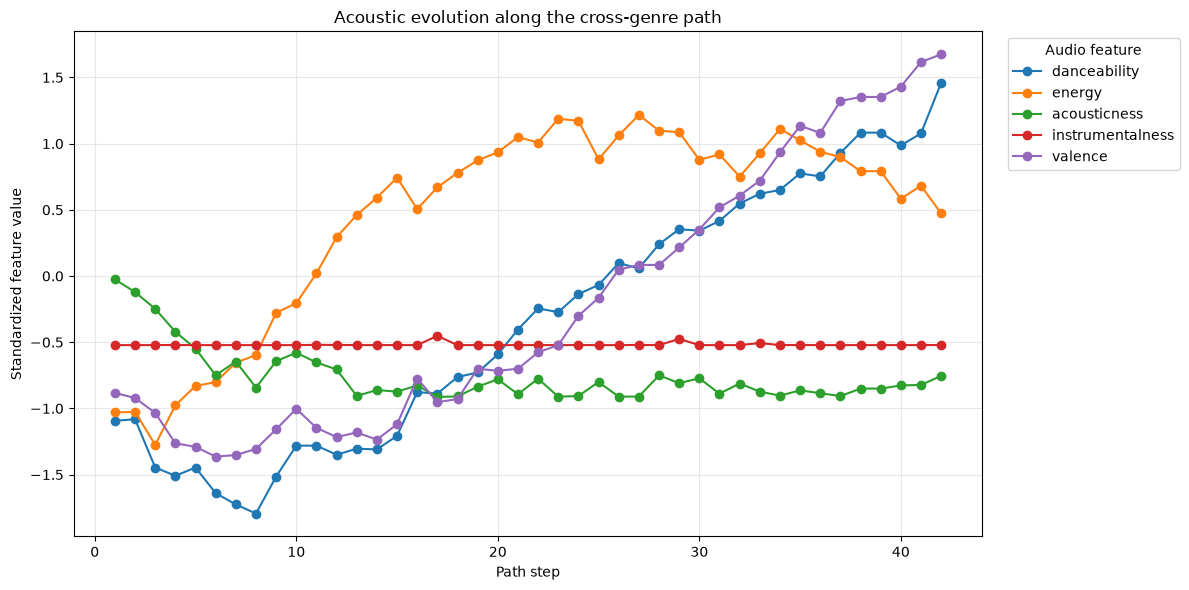

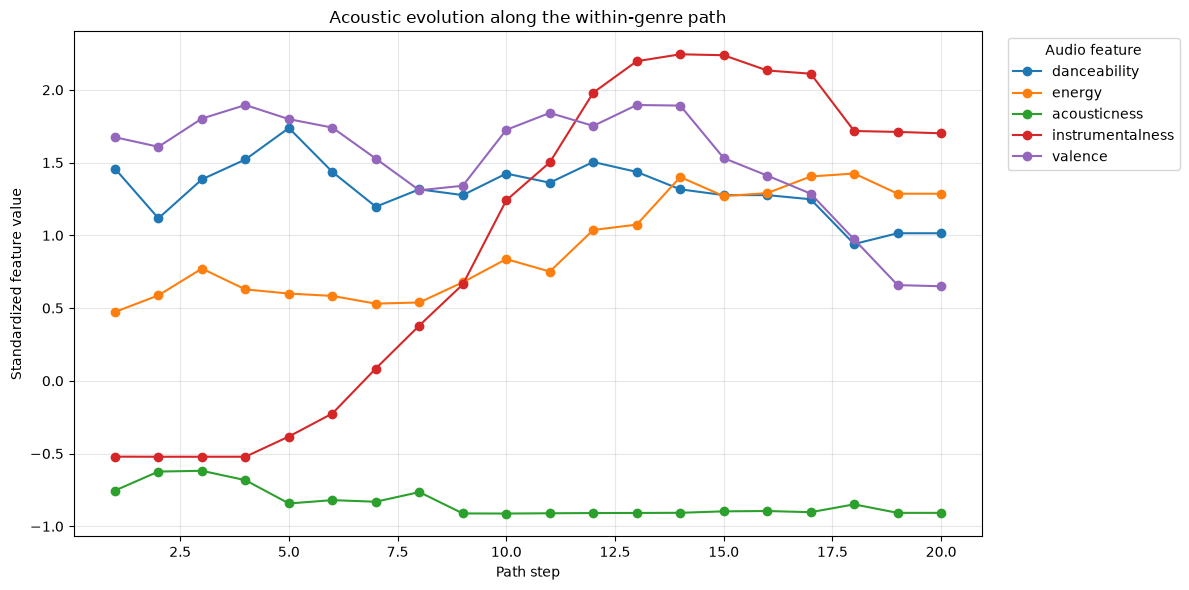

In [53]:
PATH_FEATURES = [
    "danceability",
    "energy",
    "acousticness",
    "instrumentalness",
    "valence"
]

plot_path_feature_evolution(
    path_nodes=cross_nodes,
    metadata=song_metadata,
    features=PATH_FEATURES,
    title="Acoustic evolution along the cross-genre path"
)

plot_path_feature_evolution(
    path_nodes=within_nodes,
    metadata=song_metadata,
    features=PATH_FEATURES,
    title="Acoustic evolution along the within-genre path"
)

## Introducing a hop penalty

In [57]:
def compute_song_path(
    graph,
    metadata,
    source,
    target,
    distance_attribute=DISTANCE_ATTRIBUTE,
    similarity_attribute=SIMILARITY_ATTRIBUTE,
    hop_penalty=0.01
):
    """
    Compute the minimum cumulative cosine-distance path between two songs
    and return both the node sequence and a report-ready table.
    """

    if source not in graph:
        raise nx.NodeNotFound(f"Source node {source!r} is not in the graph.")

    if target not in graph:
        raise nx.NodeNotFound(f"Target node {target!r} is not in the graph.")

    if source not in metadata.index:
        raise KeyError(f"No metadata found for source node {source!r}.")

    if target not in metadata.index:
        raise KeyError(f"No metadata found for target node {target!r}.")

    node_path = nx.shortest_path(
        graph,
        source=source,
        target=target,
        weight=lambda u, v, data: (
            float(data[distance_attribute]) + hop_penalty
        ),
        method="dijkstra"
    )

    rows = []

    for step, node in enumerate(node_path, start=1):
        row = metadata.loc[node]

        if step < len(node_path):
            next_node = node_path[step]

            edge_data = graph.get_edge_data(node, next_node)

            similarity_to_next = float(
                edge_data[similarity_attribute]
            )
            distance_to_next = float(
                edge_data[distance_attribute]
            )
        else:
            similarity_to_next = np.nan
            distance_to_next = np.nan

        rows.append({
            "Step": step,
            "Node": node,
            "Track": row.get(TRACK_COLUMN, np.nan),
            "Artist": row.get(ARTIST_COLUMN, np.nan),
            "Macro-genre": row.get(MACRO_GENRE_COLUMN, np.nan),
            "Subgenre": row.get(SUBGENRE_COLUMN, np.nan),
            "Community": row.get(COMMUNITY_COLUMN, np.nan),
            "Similarity to next": similarity_to_next,
            "Distance to next": distance_to_next
        })

    path_table = pd.DataFrame(rows)

    valid_similarities = (
        path_table["Similarity to next"]
        .dropna()
        .to_numpy()
    )

    valid_distances = (
        path_table["Distance to next"]
        .dropna()
        .to_numpy()
    )

    summary = {
        "Source": source,
        "Target": target,
        "Number of songs": len(node_path),
        "Number of transitions": len(node_path) - 1,
        "Total cosine distance": valid_distances.sum(),
        "Average similarity": valid_similarities.mean(),
        "Minimum similarity": valid_similarities.min(),
        "Maximum similarity": valid_similarities.max(),
        "Communities visited": path_table["Community"].nunique(
            dropna=True
        ),
        "Macro-genres visited": path_table["Macro-genre"].nunique(
            dropna=True
        )
    }

    return node_path, path_table, pd.Series(summary)

In [64]:
cross_nodes, cross_path, cross_summary = compute_song_path(
    graph=G,
    metadata=song_metadata,
    source=54146,
    target=71648,
    hop_penalty=0.03
)

within_nodes, within_path, within_summary = compute_song_path(
    graph=G,
    metadata=song_metadata,
    source=71648,
    target=1153,
    hop_penalty=0.03
)

print("CROSS-GENRE PATH")
display(cross_path)
display(cross_summary.to_frame("Value"))

print("\nWITHIN-GENRE PATH")
display(within_path)
display(within_summary.to_frame("Value"))

CROSS-GENRE PATH


,Step,Node,Track,Artist,Macro-genre,Subgenre,Community,Similarity to next,Distance to next
0,1,54146,Bohemian Rhapsody,Queen,Rock,rock,12,0.969019,0.030981
1,2,39959,Way to Fall,Starsailor,Classical,piano,12,0.961880,0.038120
2,3,11173,Something - Remastered 2009,The Beatles,Regional,british,12,0.953399,0.046601
3,4,17081,Santa Claus Is Comin' To Town - 1991 Remix,The Beach Boys,Rock,psych-rock,24,0.929700,0.070300
4,5,97830,Strangers (Remastered),The Kinks,Regional,british,12,0.929825,0.070175
5,6,78329,Abre Essas Pernas Pra Mim,Velhas Virgens,Alternative,punk,24,0.932477,0.067523
6,7,37136,Glass Onion - Remastered 2009,The Beatles,Rock,psych-rock,24,0.955312,0.044688
7,8,62311,Everything I Touch Turns to Tears,The Coffinshakers,Alternative,goth,24,0.965465,0.034535
8,9,76903,Espejismo,La Tropa Loca,Rock,rock-n-roll,24,0.977501,0.022499
9,10,57304,3 small words,MisterWives,Alternative,indie-pop,24,0.980801,0.019199


,Value
Source,54146.000000
Target,71648.000000
Number of songs,16.000000
Number of transitions,15.000000
Total cosine distance,0.499840
Average similarity,0.966677
Minimum similarity,0.929700
Maximum similarity,0.991533
Communities visited,3.000000
Macro-genres visited,8.000000



WITHIN-GENRE PATH


,Step,Node,Track,Artist,Macro-genre,Subgenre,Community,Similarity to next,Distance to next
0,1,71648,Shape of You - Galantis Remix,Ed Sheeran,Electronic,edm,18,0.986968,0.013032
1,2,12388,Tres Gotas De Agua Bendita,Gloria Estefan,Latin,latin,18,0.990177,0.009823
2,3,63205,El Mismo Sol - Radio Edit,Alvaro Soler;Don Lore V,Latin,latin,16,0.993172,0.006828
3,4,38059,MENEITO,Nil Moliner;Yera,Regional,spanish,16,0.980974,0.019026
4,5,103497,Mind Blown,Syn Cole,Electronic,deep-house,16,0.979350,0.020650
5,6,77897,It's Sheryl Amazing,Terrence Parker,Electronic,detroit-techno,16,0.976188,0.023812
6,7,94244,Tenderness,Orlando Voorn,Electronic,detroit-techno,7,0.984675,0.015325
7,8,18049,Bac N Da Day - Clepto's Mix,Frankie Knuckles,Electronic,chicago-house,7,0.981609,0.018391
8,9,60921,In Da Jungle - Elliot Fitch Remix,Orlando Voorn;Elliot Fitch,Electronic,detroit-techno,7,0.981921,0.018079
9,10,45833,Crazy Things at Night,Sonny Fodera,Electronic,edm,7,0.974153,0.025847


,Value
Source,71648.000000
Target,1153.000000
Number of songs,13.000000
Number of transitions,12.000000
Total cosine distance,0.209820
Average similarity,0.982515
Minimum similarity,0.970031
Maximum similarity,0.993172
Communities visited,3.000000
Macro-genres visited,3.000000


In [65]:
validate_path_examples(
    cross_path=cross_path,
    within_path=within_path
)

Cross-genre example
-------------------
Source genre: Rock
Target genre: Electronic
Different macro-genres: True

Within-genre example
--------------------
Source genre: Electronic
Target genre: Electronic
Same macro-genre: True
Different communities: True


In [66]:
cross_report = cross_path.copy()
cross_report.insert(0, "Example", "Cross-genre")

within_report = within_path.copy()
within_report.insert(0, "Example", "Within-genre")

combined_path_table = pd.concat(
    [cross_report, within_report],
    ignore_index=True
)

report_columns = [
    "Example",
    "Step",
    "Track",
    "Artist",
    "Macro-genre",
    "Community",
    "Similarity to next"
]

combined_path_table = combined_path_table[report_columns]

combined_path_table["Similarity to next"] = (
    combined_path_table["Similarity to next"].round(3)
)

display(combined_path_table)

,Example,Step,Track,Artist,Macro-genre,Community,Similarity to next
0,Cross-genre,1,Bohemian Rhapsody,Queen,Rock,12,0.969
1,Cross-genre,2,Way to Fall,Starsailor,Classical,12,0.962
2,Cross-genre,3,Something - Remastered 2009,The Beatles,Regional,12,0.953
3,Cross-genre,4,Santa Claus Is Comin' To Town - 1991 Remix,The Beach Boys,Rock,24,0.930
4,Cross-genre,5,Strangers (Remastered),The Kinks,Regional,12,0.930
5,Cross-genre,6,Abre Essas Pernas Pra Mim,Velhas Virgens,Alternative,24,0.932
6,Cross-genre,7,Glass Onion - Remastered 2009,The Beatles,Rock,24,0.955
7,Cross-genre,8,Everything I Touch Turns to Tears,The Coffinshakers,Alternative,24,0.965
8,Cross-genre,9,Espejismo,La Tropa Loca,Rock,24,0.978
9,Cross-genre,10,3 small words,MisterWives,Alternative,24,0.981


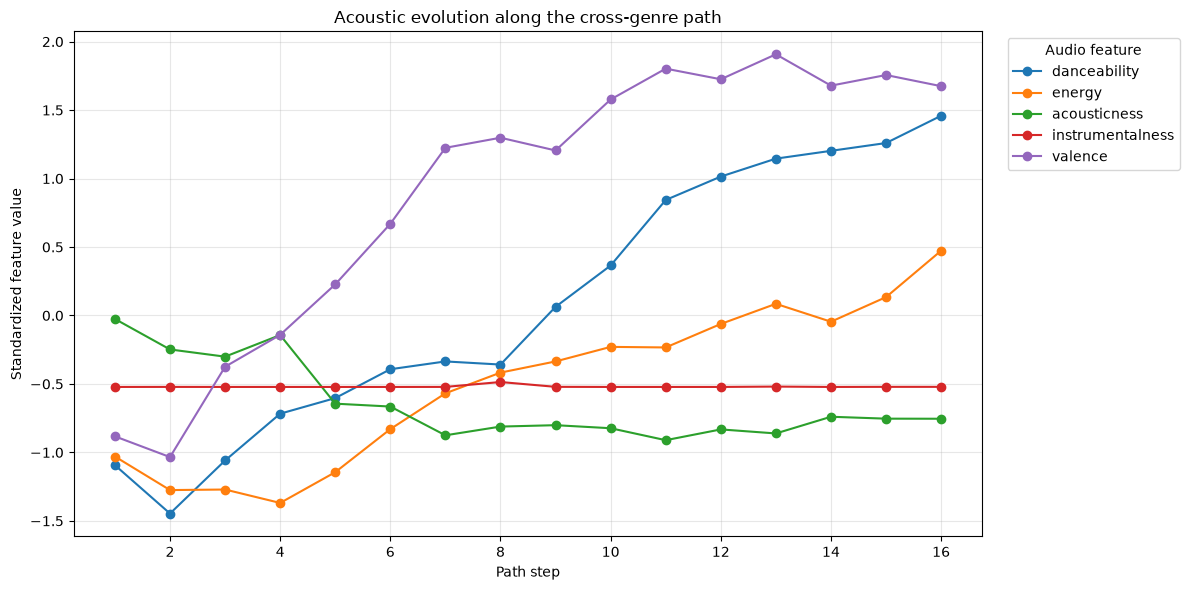

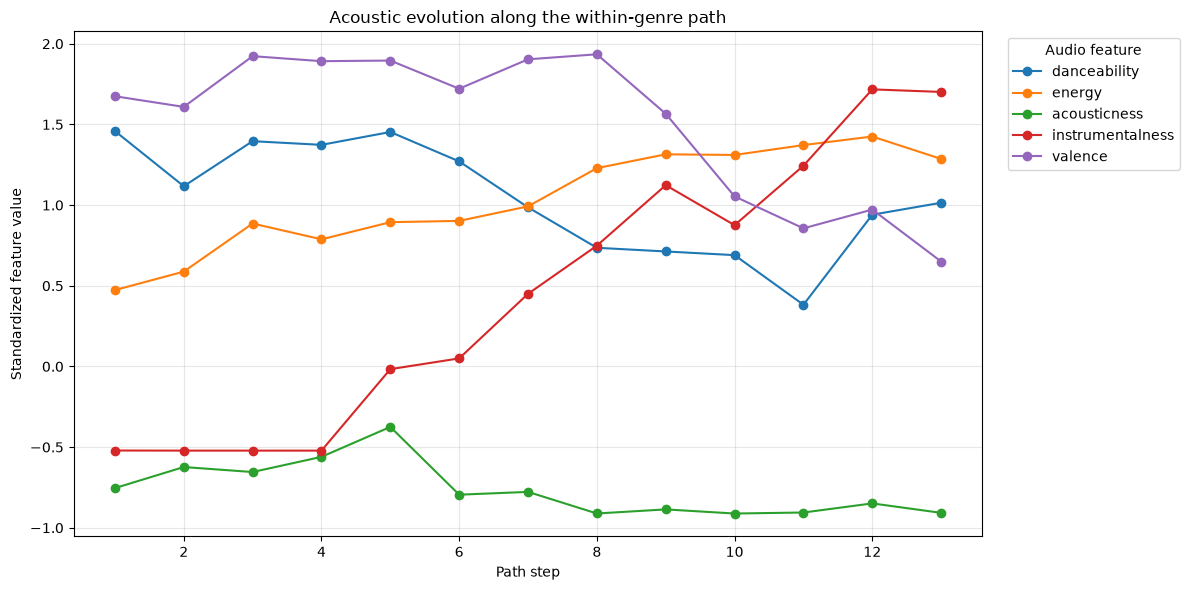

In [68]:
PATH_FEATURES = [
    "danceability",
    "energy",
    "acousticness",
    "instrumentalness",
    "valence"
]

plot_path_feature_evolution(
    path_nodes=cross_nodes,
    metadata=song_metadata,
    features=PATH_FEATURES,
    title="Acoustic evolution along the cross-genre path"
)

plot_path_feature_evolution(
    path_nodes=within_nodes,
    metadata=song_metadata,
    features=PATH_FEATURES,
    title="Acoustic evolution along the within-genre path"
)